<a href="https://colab.research.google.com/github/westhauxstripclub/frontend-slides/blob/main/31_KNN_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbors (KNN) for Regression

## Motivation: Why Should You Care?

Imagine you want to predict house prices but you don't know the exact mathematical formula. Instead, you think: *"I'll find the 5 most similar houses that already sold and see what they cost."* This intuitive idea—predict based on similar neighbors—is exactly what KNN does. Unlike linear regression which forces data into a straight line, KNN is **flexible**: it can learn curved patterns, handle multiple non-linear relationships, and adapt to local variations in your data. It's a foundation for understanding distance-based learning and why similarity matters in machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import seaborn as sns
sns.set_style("whitegrid")

## The Algorithm: What, Why, How?



**What is KNN Regression?**

KNN regression predicts a continuous target value (like price or temperature) by finding the k closest training points and averaging their target values. For example, to predict a house price, find the 5 most similar houses in your training data and predict the average of their prices. No formula, no line fitting—just neighbors voting with their actual values.

**Why Use KNN Instead of Linear Regression?**

Linear regression assumes your data follows a straight line: `y = β₀ + β₁x`. Real data is messy and rarely linear. KNN adapts locally: in one region, the relationship might be steep; in another, it might be flat. This flexibility makes KNN powerful for complex, non-linear patterns. The trade-off is simplicity: linear regression gives you an interpretable equation, while KNN gives you predictions without understanding *why*.

**How Does the Algorithm Work?**

1. **Store** the training data (lazy learner—no actual training phase)
2. **For each new point:** Calculate distance to every training point using a distance function (for example, Euclidean distance. In $R^2$ $dist(a,b) = \sqrt{(x_a-x_b)^2 + (y_a-y_b)^2}$)
3. **Find** the k points with smallest distance
4. **Predict** the average of their target values: ŷ = (y₁ + y₂ + ... + yₖ) / k

**Performance Metrics: How Do We Know If It Works?**

- **MSE (Mean Squared Error):** Average of (actual - predicted)². Penalizes large errors heavily (useful if outliers matter). Formula: MSE = (1/n)∑(yᵢ - ŷᵢ)². Lower is better.
- **MAE (Mean Absolute Error):** Average of |actual - predicted|. More interpretable because it's in same units as your target (e.g., dollars). Formula: MAE = (1/n)∑|yᵢ - ŷᵢ|. Lower is better.
- **R² Score:** Fraction of variance explained (0 to 1 scale). R² = 1 means perfect predictions; R² = 0 means no better than predicting the mean. Higher is better.

## Real Example: Predicting House Prices in California (1990s)



**The Problem:** You're a real estate agent and need to estimate a house's market value. You have data on 20,000 historical sales with features like median income in the area, house age, number of rooms, population density, and geographic location. Does a linear model make sense? Probably not—expensive coastal areas and affordable inland areas have completely different price-to-feature relationships. KNN's local averaging handles this naturally: when predicting a coastal house, it finds similar coastal houses; for inland, it finds inland comparables.

In [2]:
# Load California housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target  # House prices (in hundreds of thousands of dollars)

# Create DataFrame for readability
df = pd.DataFrame(X, columns=housing.feature_names)
df['Price'] = y

print(df.head())
print(f"\nDataset shape: {X.shape}")
print(f"Price range: ${y.min():.2f}k - ${y.max():.2f}k (in hundreds of thousands)")
print(f"\nFeatures: {list(housing.feature_names)}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset shape: (20640, 8)
Price range: $0.15k - $5.00k (in hundreds of thousands)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [4]:
# Split and scale (KNN is distance-based, so scaling matters!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")

Train set: 16512 samples
Test set: 4128 samples


In [5]:
# Train KNN regressor with k=5
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = knn_reg.predict(X_train_scaled)
y_pred_test = knn_reg.predict(X_test_scaled)

# Evaluate
print("KNN REGRESSION RESULTS (k=5):")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"\nTrain MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"\nTrain R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_test):.4f}")

KNN REGRESSION RESULTS (k=5):
Train MSE: 0.2715
Test MSE:  0.4324

Train MAE: 0.3552
Test MAE:  0.4462

Train R²: 0.7969
Test R²:  0.6700


## Visualizing Predictions

Actual vs predicted prices for first 50 test samples.

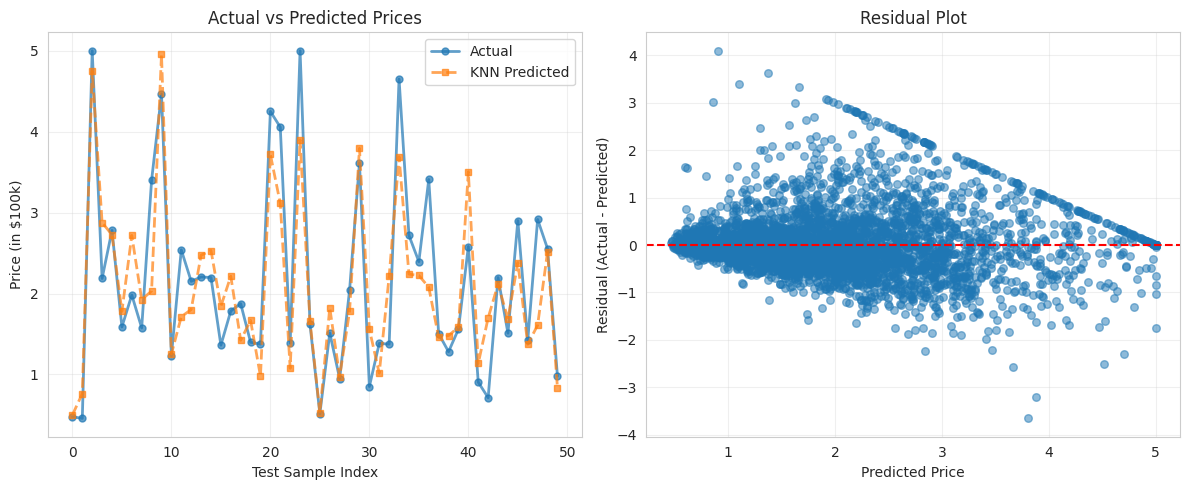

Mean residual (should be ≈0): 0.017447
Residual std dev (should be ~ 1): 0.6574


In [7]:
n_show = 50
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
x_idx = np.arange(n_show)
plt.plot(x_idx, y_test[:n_show], 'o-', label='Actual', alpha=0.7, linewidth=2, markersize=5)
plt.plot(x_idx, y_pred_test[:n_show], 's--', label='KNN Predicted', alpha=0.7, linewidth=2, markersize=5)
plt.xlabel('Test Sample Index')
plt.ylabel('Price (in $100k)')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residuals
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.5, s=30)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean residual (should be ≈0): {residuals.mean():.6f}")
print(f"Residual std dev (should be ~ 1): {residuals.std():.4f}")

## Comparing KNN with Multiple Linear Regression



**Why Compare Them?** Both predict continuous values, but they make different assumptions. Linear regression assumes all your data follows one global trend (e.g., "higher income → higher price, always"). KNN assumes data has local patterns (e.g., "wealthy coastal neighborhoods have different income-to-price relationships than poor inland areas"). Which assumption better fits reality? Let's measure using MSE and R²—lower MSE and higher R² mean better predictions.

In [8]:
# Train Multiple Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin_train = lin_reg.predict(X_train_scaled)
y_pred_lin_test = lin_reg.predict(X_test_scaled)

print("LINEAR REGRESSION RESULTS:")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_lin_train):.4f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_lin_test):.4f}")
print(f"\nTrain R²: {r2_score(y_train, y_pred_lin_train):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_lin_test):.4f}")

LINEAR REGRESSION RESULTS:
Train MSE: 0.5179
Test MSE:  0.5559

Train R²: 0.6126
Test R²:  0.5758



            Model  Train MSE  Test MSE  Train R²  Test R²
        KNN (k=5)   0.271502  0.432422  0.796898 0.670010
Linear Regression   0.517933  0.555892  0.612551 0.575788


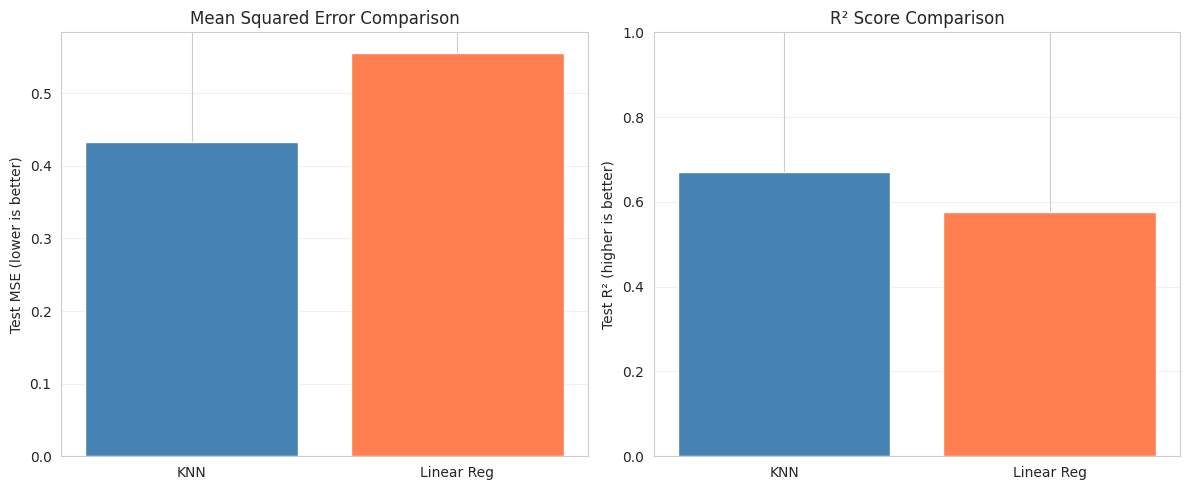

In [9]:
# Side-by-side comparison
comparison = pd.DataFrame({
    'Model': ['KNN (k=5)', 'Linear Regression'],
    'Train MSE': [mean_squared_error(y_train, y_pred_train), mean_squared_error(y_train, y_pred_lin_train)],
    'Test MSE': [mean_squared_error(y_test, y_pred_test), mean_squared_error(y_test, y_pred_lin_test)],
    'Train R²': [r2_score(y_train, y_pred_train), r2_score(y_train, y_pred_lin_train)],
    'Test R²': [r2_score(y_test, y_pred_test), r2_score(y_test, y_pred_lin_test)]
})

print("\n" + "="*70)
print(comparison.to_string(index=False))
print("="*70)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['KNN', 'Linear Reg']
test_mse = [mean_squared_error(y_test, y_pred_test), mean_squared_error(y_test, y_pred_lin_test)]
test_r2 = [r2_score(y_test, y_pred_test), r2_score(y_test, y_pred_lin_test)]

axes[0].bar(models, test_mse, color=['steelblue', 'coral'])
axes[0].set_ylabel('Test MSE (lower is better)')
axes[0].set_title('Mean Squared Error Comparison')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(models, test_r2, color=['steelblue', 'coral'])
axes[1].set_ylabel('Test R² (higher is better)')
axes[1].set_title('R² Score Comparison')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Where KNN Shines: Capturing Non-Linear Patterns

**The Limitation of Linear Regression:** Linear regression assumes a straight-line relationship. But real data is often curved, has local bumps, or follows piecewise patterns. Let's create synthetic data where linear regression fails but KNN succeeds.

NON-LINEAR DATA: y = x² + noise

Linear Regression Test MSE: 7.5117
KNN (k=5) Test MSE:          0.9968

Linear R²: -0.0562
KNN R²:    0.8598


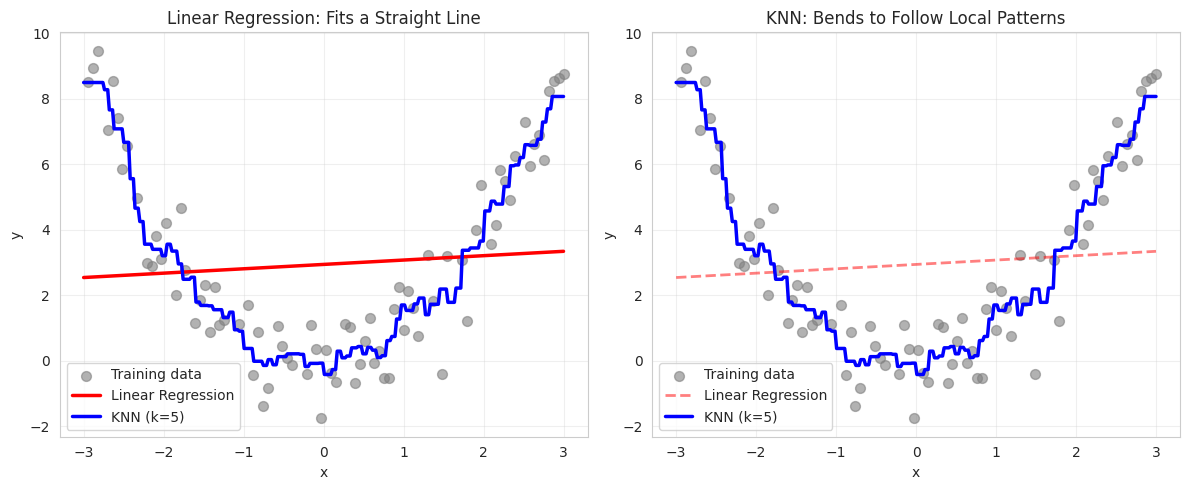


✓ KEY INSIGHT: KNN captures the parabola shape; linear regression only sees an average trend.


In [10]:
# Create non-linear synthetic data: y = x^2 with noise
np.random.seed(42)
X_nonlinear = np.linspace(-3, 3, 100).reshape(-1, 1)
y_nonlinear = X_nonlinear.ravel()**2 + np.random.normal(0, 1, 100)  # Parabola + noise

# Split
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_nonlinear, y_nonlinear, test_size=0.2, random_state=42
)

# Train both models
lin_reg_nl = LinearRegression()
lin_reg_nl.fit(X_train_nl, y_train_nl)

knn_reg_nl = KNeighborsRegressor(n_neighbors=5)
knn_reg_nl.fit(X_train_nl, y_train_nl)

# Predictions on fine grid for visualization
X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
y_lin_pred = lin_reg_nl.predict(X_plot)
y_knn_pred = knn_reg_nl.predict(X_plot)

# Evaluate
print("NON-LINEAR DATA: y = x² + noise")
print(f"\nLinear Regression Test MSE: {mean_squared_error(y_test_nl, lin_reg_nl.predict(X_test_nl)):.4f}")
print(f"KNN (k=5) Test MSE:          {mean_squared_error(y_test_nl, knn_reg_nl.predict(X_test_nl)):.4f}")
print(f"\nLinear R²: {r2_score(y_test_nl, lin_reg_nl.predict(X_test_nl)):.4f}")
print(f"KNN R²:    {r2_score(y_test_nl, knn_reg_nl.predict(X_test_nl)):.4f}")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train_nl, y_train_nl, alpha=0.6, s=50, label='Training data', color='gray')
plt.plot(X_plot, y_lin_pred, 'r-', linewidth=2.5, label='Linear Regression')
plt.plot(X_plot, y_knn_pred, 'b-', linewidth=2.5, label='KNN (k=5)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression: Fits a Straight Line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_train_nl, y_train_nl, alpha=0.6, s=50, label='Training data', color='gray')
plt.plot(X_plot, y_lin_pred, 'r--', linewidth=2, alpha=0.5, label='Linear Regression')
plt.plot(X_plot, y_knn_pred, 'b-', linewidth=2.5, label='KNN (k=5)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('KNN: Bends to Follow Local Patterns')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ KEY INSIGHT: KNN captures the parabola shape; linear regression only sees an average trend.")

## Tuning k: The Complexity Trade-off

**The Problem with Choosing k:** If k=1 (one neighbor), you memorize the training data—great train accuracy, terrible test accuracy (overfitting). If k=50 (fifty neighbors), you average out local patterns—worse at capturing real variation (underfitting). The plot below shows this classic bias-variance trade-off. Your job is to find the sweet spot where test error is lowest, which we do by testing different k values on held-out test data.

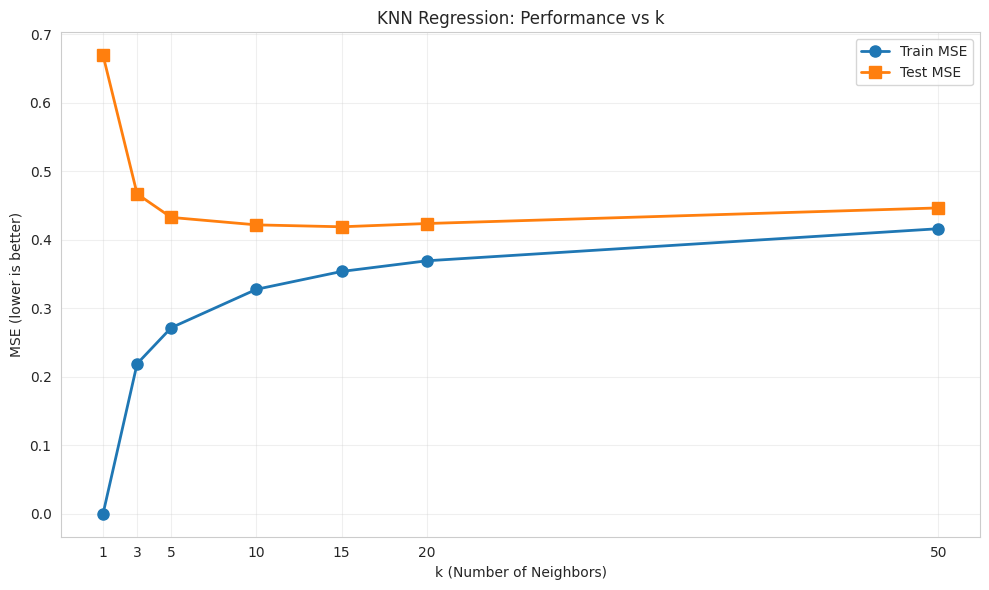


Optimal k value (lowest test MSE): 15
Test MSE at k=15: 0.4188


In [11]:
# Test different k values
k_values = [1, 3, 5, 10, 15, 20, 50]
train_mse = []
test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_mse.append(mean_squared_error(y_train, knn.predict(X_train_scaled)))
    test_mse.append(mean_squared_error(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_mse, 'o-', label='Train MSE', linewidth=2, markersize=8)
plt.plot(k_values, test_mse, 's-', label='Test MSE', linewidth=2, markersize=8)
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('MSE (lower is better)')
plt.title('KNN Regression: Performance vs k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmin(test_mse)]
print(f"\nOptimal k value (lowest test MSE): {best_k}")
print(f"Test MSE at k={best_k}: {min(test_mse):.4f}")

---

## GROUP WORK: Implement KNN on Diabetes Dataset

**Your Task:** Use the diabetes dataset (10 patient measurements to predict disease progression). Implement KNN regression, compare with linear regression, and discover *where KNN wins*.

**Step 1: Load, Explore, Split**


In [12]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

In [14]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Use AI to learn how The code `X_scaled = scaler.fit_transform(X)` standardizes your dataset X.

In [15]:
# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (353, 10)
Test shape: (89, 10)


__Step 2: Train Both Models__

In [18]:
# Implement KNN with k=5
knn_diabetes = KNeighborsRegressor(n_neighbors=5)
knn_diabetes.fit(X_train, y_train)
print("KNN Regressor with k=5 successfully trained on diabetes dataset!")

KNN Regressor with k=5 successfully trained on diabetes dataset!


In [19]:
# Predictions
y_pred_knn_train = knn_diabetes.predict(X_train)
y_pred_knn_test = knn_diabetes.predict(X_test)

# Evaluation Metrics
print("KNN REGRESSION ON DIABETES (k=5):")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_knn_train):.4f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_knn_test):.4f}")
print(f"\nTrain MAE: {mean_absolute_error(y_train, y_pred_knn_train):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_knn_test):.4f}")
print(f"\nTrain R²:  {r2_score(y_train, y_pred_knn_train):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred_knn_test):.4f}")

KNN REGRESSION ON DIABETES (k=5):
Train MSE: 2528.5918
Test MSE:  3019.0755

Train MAE: 39.6663
Test MAE:  42.7708

Train R²:  0.5839
Test R²:   0.4302


In [20]:
# Implement Linear Regression
lin_diabetes = LinearRegression()
lin_diabetes.fit(X_train, y_train)
print("Multiple Linear Regression successfully trained on diabetes dataset!")

Multiple Linear Regression successfully trained on diabetes dataset!


In [21]:
# Predictions
y_pred_lin_train = lin_diabetes.predict(X_train)
y_pred_lin_test = lin_diabetes.predict(X_test)

# Evaluation Metrics
print("LINEAR REGRESSION ON DIABETES:")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_lin_train):.4f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_lin_test):.4f}")
print(f"\nTrain MAE: {mean_absolute_error(y_train, y_pred_lin_train):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_lin_test):.4f}")
print(f"\nTrain R²:  {r2_score(y_train, y_pred_lin_train):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred_lin_test):.4f}")

LINEAR REGRESSION ON DIABETES:
Train MSE: 2868.5497
Test MSE:  2900.1936

Train MAE: 43.4835
Test MAE:  42.7941

Train R²:  0.5279
Test R²:   0.4526



**Step 3: Investigate & Discuss**

1. **Which Model Wins?** Does KNN or linear regression have lower test MSE? Why might one be better? (Hint: does disease progression follow a linear trend or local patterns?) *KNN has lower train MSE but higher test MSE meaning the model may have overfitted the data to the training set. Linear regression may be better for this application because the difference between train and test MSE scores would point to the idea that the linear model is better fitting.*

2. **Feature Scaling Matters:** Train KNN on *unscaled* data. Does test MSE get worse? Explain why distance-based models need scaling but linear regression doesn't. *Test MSE stays the exact same but train MSE gets much worse without scaling. Distance-based models need scaling because without it, the model becomes single-featured and loses out on the generality of features (being overwhelmed by the feature with the greatest range).*

3. **Find the Optimal k:** Test different values of k. Plot test MSE vs k. Where does it bottom out? Why doesn't k=1? *The optimal k is k=6 because that is where the MSE value reaches its minima. k=1 is not an ideal choice because it leads to overfitting since every point is its own nearest neighbor, leading the model to memorize the training data. As such, this makes the model very sensitive to training noise.*

4. **Interpretability:** A KNN prediction: "Patient's progression is 100 because 5 similar patients had values [98, 99, 100, 101, 102]." A linear prediction: "Progression = 50 + 2.5×(Feature1) - 1.2×(Feature2) + ..." Which can a doctor understand? Which reveals *why*? *A doctor can understand both predictions but they have different use cases. The KNN model is useful as a clinical case-based reasoning module where the model aligns the patient's status with the k-nearest fit patients. The linear model, however, is structured more like a calculation resulting in a risk score based on various factors with their own unique weighting in proportion to the model as a whole. Linear regression models are more useful in determining *why* as oppposed to KNN models being more useful for determining *similarity/clustering*. For example: for every unit increase in Feature1, increase risk factor by 2.5 units **(... + 2.5×(Feature1) - ...)** .*

5. **When Would You Use KNN Here?** If disease progression has non-linear patterns (e.g., age affects risk differently for young vs old patients), KNN's local reasoning wins. How would you test if this is true? *To determine the usefulness of KNN in this dataset, we can plot the residuals of the linear regression model and try to find a pattern aside from randomness that curves along the data. Additionally, we can add polynomial terms to the linear model and test if it improves the test error; if it does, the data is non-linear. After doing these, we can then compare between an optimal KNN and linear/polynomial regression to find most accurate correlation.*

In [23]:
from sklearn.model_selection import train_test_split

# Split using unscaled original X and y
X_train_unscaled, X_test_unscaled, y_train_unscaled, y_test_unscaled = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit KNN (k=5) on unscaled data
knn_unscaled = KNeighborsRegressor(n_neighbors=5)
knn_unscaled.fit(X_train_unscaled, y_train_unscaled)

# Evaluate
y_pred_unscaled_test = knn_unscaled.predict(X_test_unscaled)
mse_unscaled = mean_squared_error(y_test_unscaled, y_pred_unscaled_test)

print("KNN ON UNSCALED DIABETES DATA (k=5):")
print(f"Unscaled Test MSE: {mse_unscaled:.4f}")
print(f"Scaled Test MSE:   3019.0755")

KNN ON UNSCALED DIABETES DATA (k=5):
Unscaled Test MSE: 3019.0755
Scaled Test MSE:   3019.0755


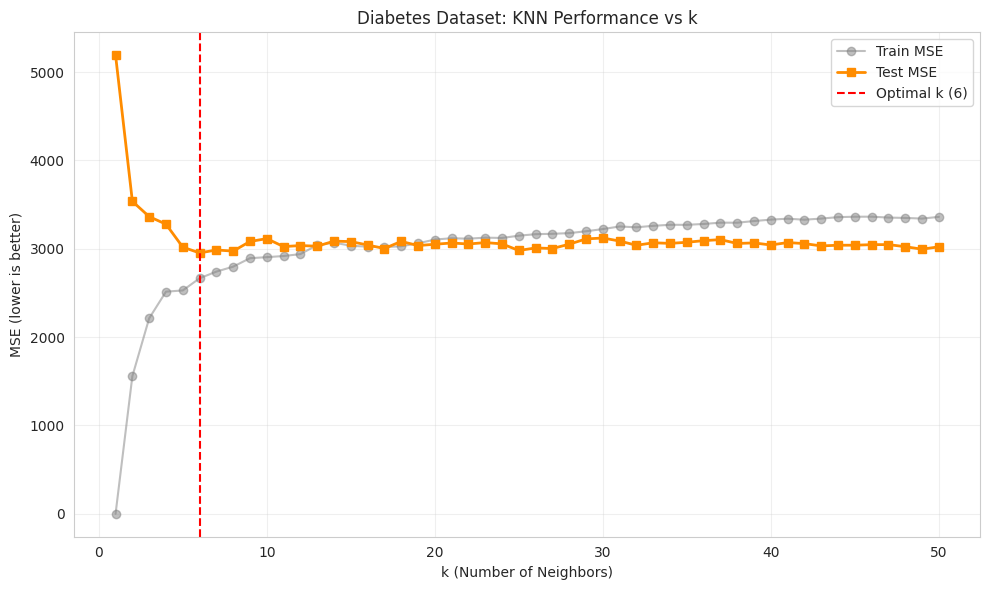

Optimal k: 6
Lowest Test MSE at k=6: 2953.1670


In [25]:
# 3. Find the Optimal k
# Test a wide range of k values
k_range = list(range(1, 51))
train_mses = []
test_mses = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_mses.append(mean_squared_error(y_train, knn.predict(X_train)))
    test_mses.append(mean_squared_error(y_test, knn.predict(X_test)))

# Identify optimal k
best_k_idx = np.argmin(test_mses)
best_k_val = k_range[best_k_idx]
min_test_mse = test_mses[best_k_idx]

# Plot Test MSE vs k
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_mses, 'o-', label='Train MSE', color='gray', alpha=0.5)
plt.plot(k_range, test_mses, 's-', label='Test MSE', color='darkorange', linewidth=2)
plt.axvline(x=best_k_val, color='red', linestyle='--', label=f'Optimal k ({best_k_val})')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('MSE (lower is better)')
plt.title('Diabetes Dataset: KNN Performance vs k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal k: {best_k_val}")
print(f"Lowest Test MSE at k={best_k_val}: {min_test_mse:.4f}")

5-Fold CV Root MSE (Lower is Better):
Linear Regression: 54.71
Polynomial Regression (deg=2): 59.12
KNN Regressor (k=6): 59.40


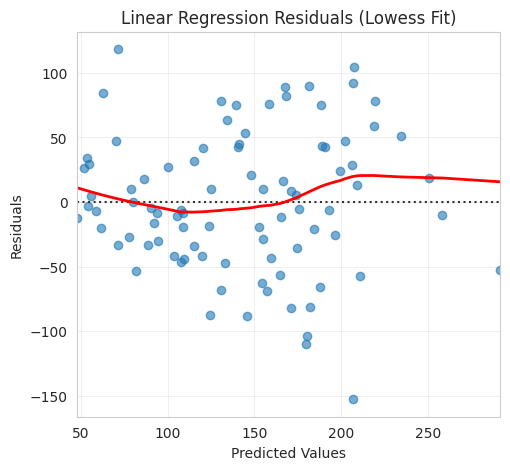

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Residual Analysis for Linear Regression
residuals_lin = y_test - y_pred_lin_test

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.residplot(x=y_pred_lin_test, y=residuals_lin, lowess=True,
             line_kws={'color': 'red', 'lw': 2}, scatter_kws={'alpha': 0.6})
plt.title('Linear Regression Residuals (Lowess Fit)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True, alpha=0.3)

# 2. Compare Cross-Validation scores of Linear, Polynomial, and KNN
lin_cv_scores = cross_val_score(LinearRegression(), X_scaled, y, cv=5, scoring='neg_mean_squared_error')
knn_cv_scores = cross_val_score(KNeighborsRegressor(n_neighbors=6), X_scaled, y, cv=5, scoring='neg_mean_squared_error')

# Create a Polynomial Regression model (degree=2) for non-linear comparison
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_cv_scores = cross_val_score(poly_model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')

print("5-Fold CV Root MSE (Lower is Better):")
print(f"Linear Regression: {np.sqrt(-lin_cv_scores.mean()):.2f}")
print(f"Polynomial Regression (deg=2): {np.sqrt(-poly_cv_scores.mean()):.2f}")
print(f"KNN Regressor (k=6): {np.sqrt(-knn_cv_scores.mean()):.2f}")